# HW7 Task 1: Forecasting football event usage

This notebook analyses the daily average number of different football events opened by iOS users in Croatia and compares a few simple forecasting approaches.

In [1]:
from pathlib import Path

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.color': '#555555',
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#cccccc',
})

COLORS = {
    'series': '#1f4e79',
    'ma': '#d95f02',
    'train': '#1f4e79',
    'test': '#222222',
    'ARIMA': '#2a9d8f',
    'ES': '#e76f51',
    'naive': '#6c757d',
    'seasonal_naive': '#8f5cc2',
    'mean': '#c0841a',
}

DATA_PATH = Path('data/avg_football_events_ios_croatia.csv')
OUTPUT_DIR = Path('outputs')
FIGURE_DIR = OUTPUT_DIR / 'figures'
TASK2_OUTPUT = Path('../task2/forecast_results_for_superset.csv')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def format_date_axis(ax, interval=2):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


## 1. Load the data

The series comes from the query result saved to CSV.

In [2]:
# Read the daily series and keep the dates in order.
df = pd.read_csv(DATA_PATH, parse_dates=['ev_date'])
df = df.sort_values('ev_date').set_index('ev_date')
df = df.asfreq('D')

# Fill gaps only if any dates are missing.
missing_dates = int(df['avg_events_per_user'].isna().sum())
if missing_dates > 0:
    df['avg_events_per_user'] = df['avg_events_per_user'].interpolate(method='time')
    print(f'Missing dates found: {missing_dates}. Filled with time interpolation.')
else:
    print('No missing dates were found, so the interpolation step did not change the series.')

df.head()


No missing dates were found, so the interpolation step did not change the series.


,avg_events_per_user
ev_date,
2024-01-01,2.6269
2024-01-02,3.4584
2024-01-03,3.5941
2024-01-04,3.4215
2024-01-05,3.7686


## 2. Original series and 7-day moving average

A 7-day moving average makes sense here because the series is daily and the usage pattern is weekly.

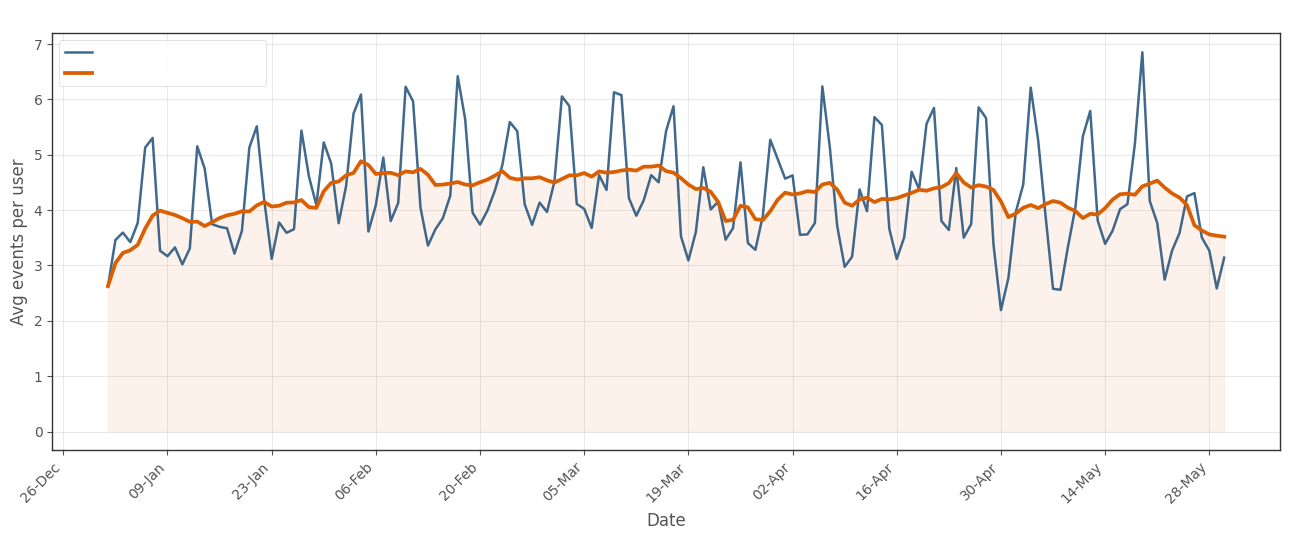

In [3]:
# Weekly smoothing is enough here.
df['ma_7'] = df['avg_events_per_user'].rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(
    df.index,
    df['avg_events_per_user'],
    label='Original series',
    linewidth=1.8,
    color=COLORS['series'],
    alpha=0.85,
)
ax.plot(
    df.index,
    df['ma_7'],
    label='7-day moving average',
    linewidth=2.7,
    color=COLORS['ma'],
)
ax.fill_between(df.index, df['ma_7'].values, alpha=0.08, color=COLORS['ma'])
ax.set_title('Average football events opened per user')
ax.set_xlabel('Date')
ax.set_ylabel('Avg events per user')
format_date_axis(ax, interval=2)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'series_and_ma7.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Decomposition

I use both STL and classical additive decomposition with a weekly period of 7 days.

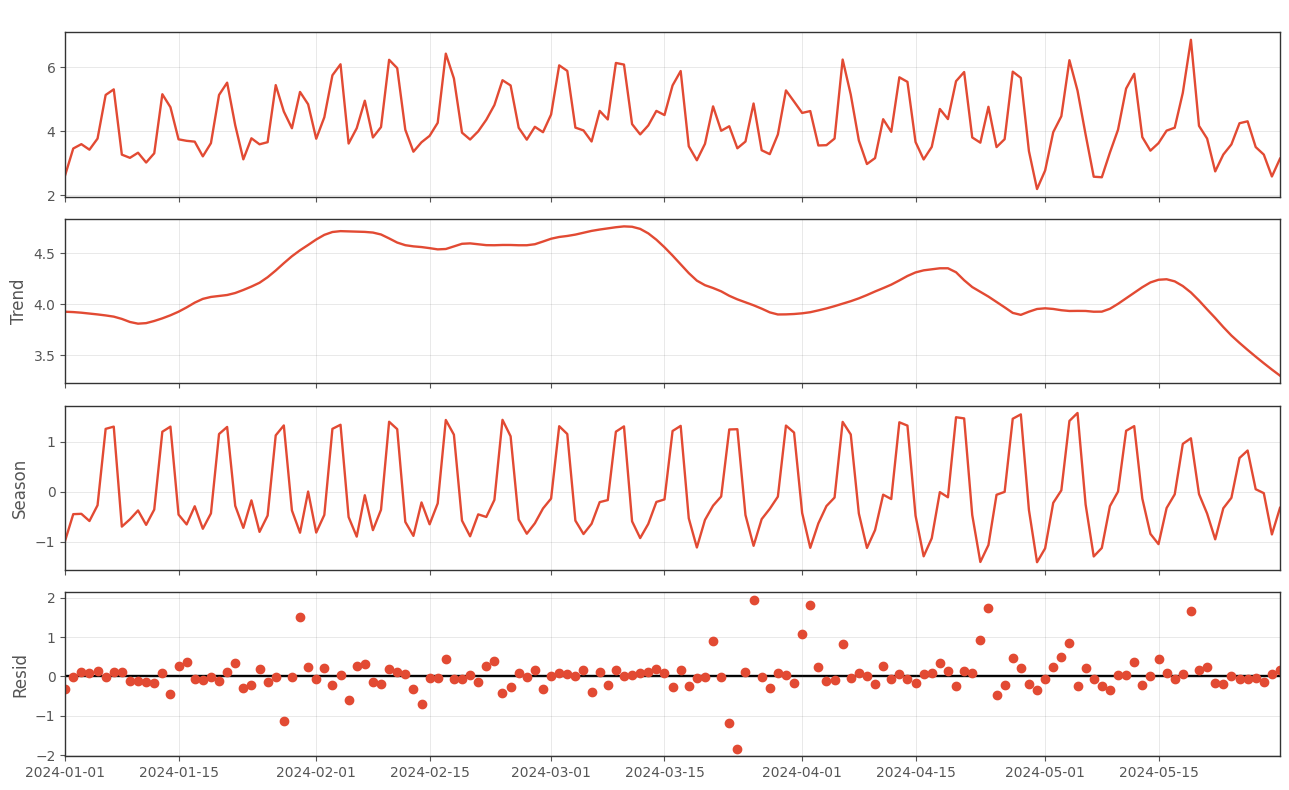

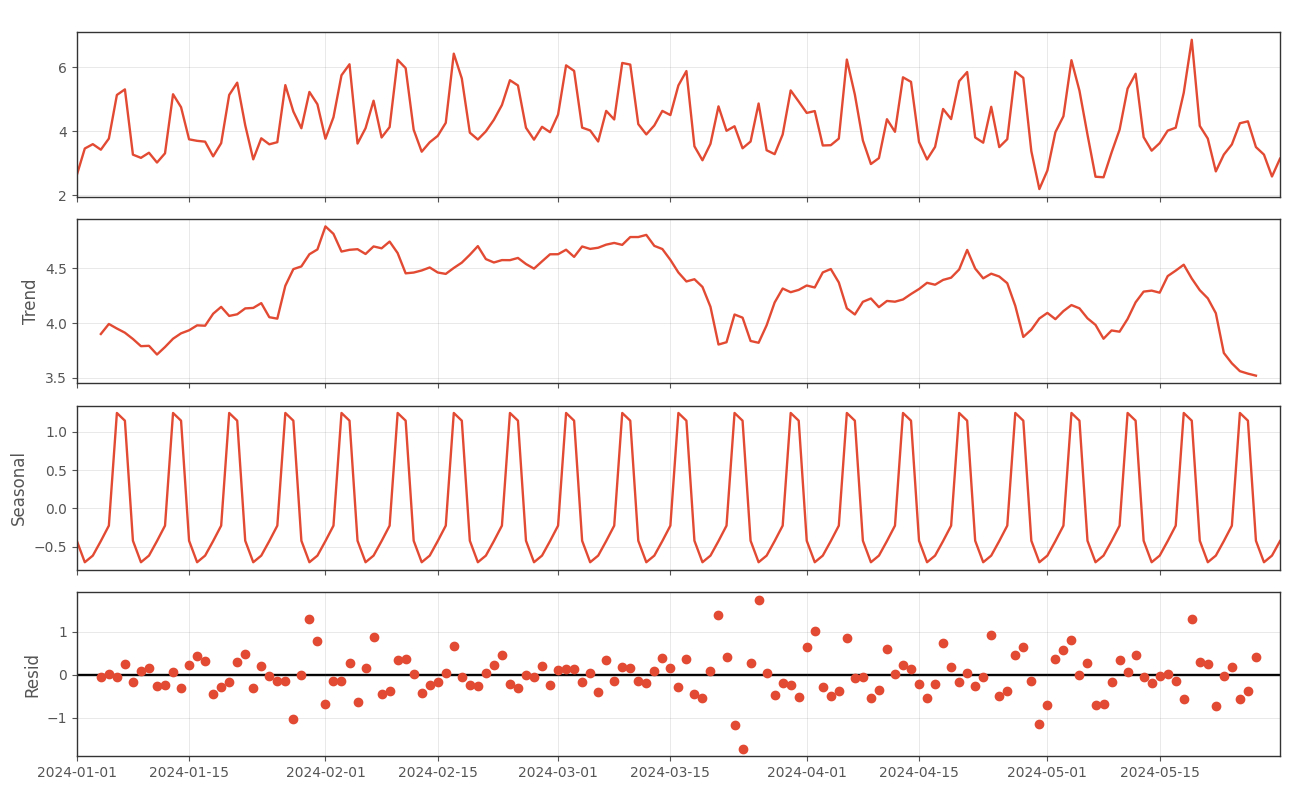

In [4]:
series = df['avg_events_per_user']

stl_result = STL(series, period=7, robust=True).fit()
classical_result = seasonal_decompose(series, model='additive', period=7)

fig = stl_result.plot()
fig.set_size_inches(13, 8)
for ax in fig.axes:
    ax.grid(alpha=0.18)
    if ax.lines:
        for line in ax.lines:
            line.set_linewidth(1.7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

fig = classical_result.plot()
fig.set_size_inches(13, 8)
for ax in fig.axes:
    ax.grid(alpha=0.18)
    if ax.lines:
        for line in ax.lines:
            line.set_linewidth(1.7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'classical_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


The trend is fairly stable, with a few short shifts rather than one long move. The seasonal part is clearly weekly, which matches the daily sports pattern. Residuals still keep a few spikes.

STL is more flexible because it lets the trend and seasonal pattern adapt more smoothly over time, while classical decomposition is more rigid and assumes a fixed structure.

## 4. Stationarity

I use ADF on the original and differenced series, and add KPSS as a second check.

In [5]:
def run_adf(series, label):
    result = adfuller(series.dropna())
    return {
        'series': label,
        'test': 'ADF',
        'statistic': result[0],
        'p_value': result[1],
        'lags': result[2],
        'n_obs': result[3],
    }

def run_kpss(series, label):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'series': label,
        'test': 'KPSS',
        'statistic': result[0],
        'p_value': result[1],
        'lags': result[2],
        'n_obs': len(series.dropna()),
    }

# First difference for the standard ARIMA stationarity check.
df['diff_1'] = df['avg_events_per_user'].diff()

# ADF and KPSS give the two usual null hypotheses.
stationarity_rows = [
    run_adf(df['avg_events_per_user'], 'original'),
    run_adf(df['diff_1'], 'first_difference'),
    run_kpss(df['avg_events_per_user'], 'original'),
    run_kpss(df['diff_1'], 'first_difference'),
]

stationarity_df = pd.DataFrame(stationarity_rows)
stationarity_df.to_csv(OUTPUT_DIR / 'stationarity_check.csv', index=False)
stationarity_df


,series,test,statistic,p_value,lags,n_obs
0,original,ADF,-2.973232,3.747098e-02,11,139
1,first_difference,ADF,-17.616594,3.856642e-30,5,144
2,original,KPSS,0.233243,1.000000e-01,9,151
3,first_difference,KPSS,0.394020,7.973265e-02,70,150


The differenced series is a safer option for ARIMA if the original one looks borderline. Here the weekly pattern matters more than any strong long trend.

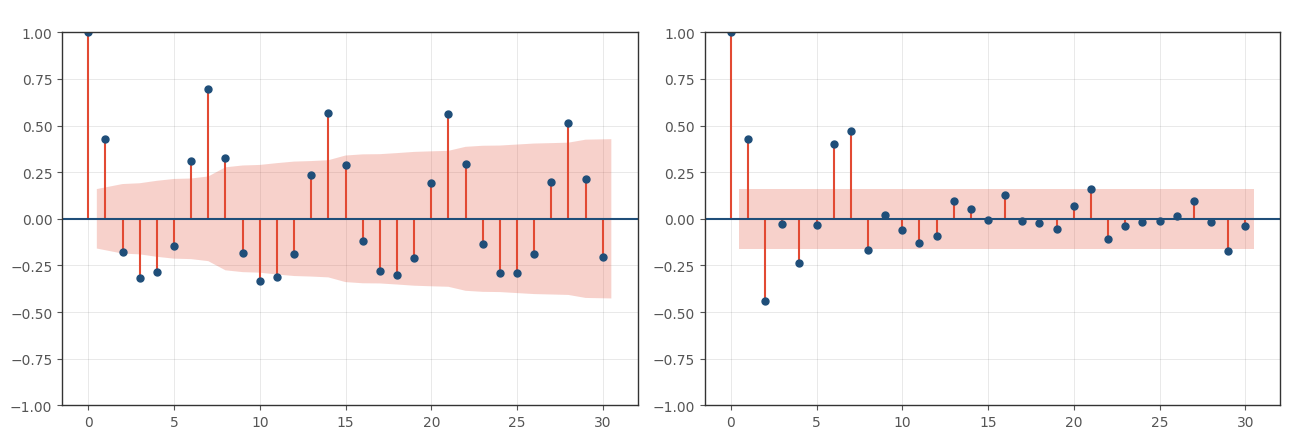

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(
    df['avg_events_per_user'].dropna(),
    ax=axes[0],
    lags=30,
    color=COLORS['series'],
)
plot_pacf(
    df['avg_events_per_user'].dropna(),
    ax=axes[1],
    lags=30,
    method='ywm',
    color=COLORS['series'],
)
axes[0].set_title('ACF of original series')
axes[1].set_title('PACF of original series')
for ax in axes:
    ax.grid(alpha=0.18)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Train/test split

The last 15 days are kept as the test window.

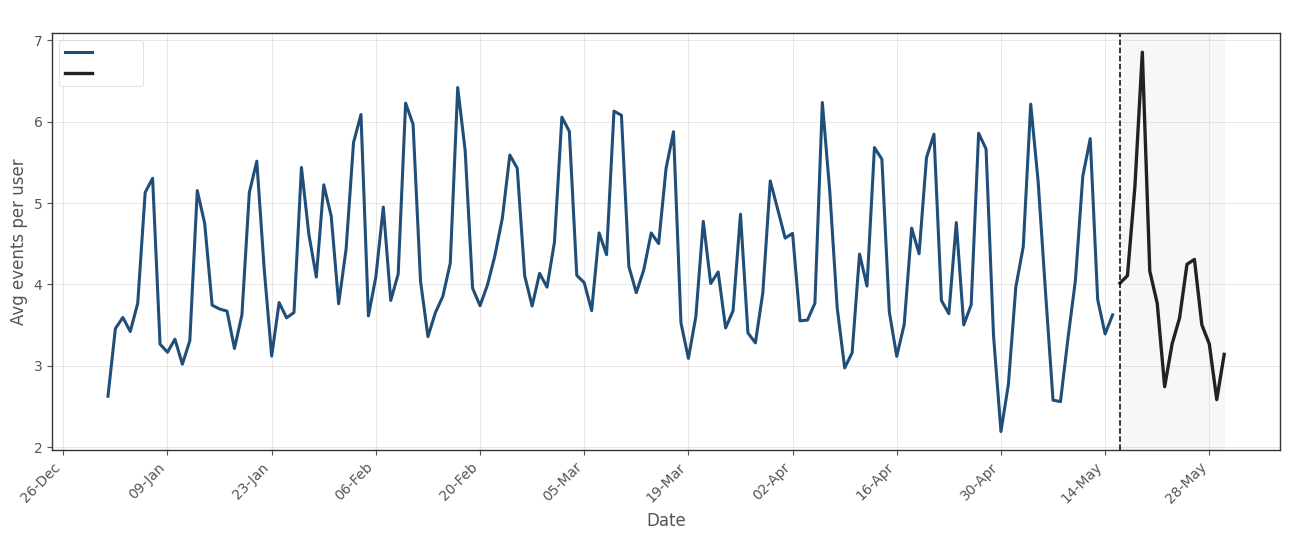

In [7]:
train = df.loc['2024-01-01':'2024-05-15', 'avg_events_per_user']
test = df.loc['2024-05-16':'2024-05-30', 'avg_events_per_user']

assert len(test) == 15
assert train.index.max() == pd.Timestamp('2024-05-15')
assert test.index.min() == pd.Timestamp('2024-05-16')

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train.index, train, label='Train', linewidth=2.2, color=COLORS['train'])
ax.plot(test.index, test, label='Test', linewidth=2.4, color=COLORS['test'])
ax.axvline(pd.Timestamp('2024-05-16'), color='black', linestyle='--', linewidth=1.1)
ax.axvspan(test.index.min(), test.index.max(), color='#999999', alpha=0.08)
ax.set_title('Train/test split')
ax.set_xlabel('Date')
ax.set_ylabel('Avg events per user')
format_date_axis(ax, interval=2)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. ARIMA

I keep the grid search small and select the lowest AIC.

In [8]:
arima_candidates = []
best_arima_model = None
best_arima_order = None
best_arima_aic = np.inf

for p in range(5):
    for d in range(3):
        for q in range(5):
            order = (p, d, q)
            try:
                model = ARIMA(train, order=order)
                fitted = model.fit()
                arima_candidates.append({'order': order, 'aic': fitted.aic})
                if fitted.aic < best_arima_aic:
                    best_arima_aic = fitted.aic
                    best_arima_order = order
                    best_arima_model = fitted
            except Exception:
                continue

print(f'Selected ARIMA order: {best_arima_order}')
print(f'Best ARIMA AIC: {best_arima_aic:.2f}')

arima_fitted = best_arima_model.fittedvalues
arima_forecast = best_arima_model.forecast(steps=len(test))
arima_forecast.index = test.index


Selected ARIMA order: (4, 0, 4)
Best ARIMA AIC: 261.39


## 7. Exponential Smoothing

I start with additive trend and weekly seasonality, then fall back to a simpler version if needed.

In [9]:
es_mode = 'additive trend + additive seasonality'

try:
    es_model = ExponentialSmoothing(
        train,
        trend='add',
        seasonal='add',
        seasonal_periods=7,
        initialization_method='estimated'
    ).fit(optimized=True)
except Exception:
    es_mode = 'trend only fallback'
    es_model = ExponentialSmoothing(
        train,
        trend='add',
        seasonal=None,
        initialization_method='estimated'
    ).fit(optimized=True)

print(f'ES specification used: {es_mode}')

es_fitted = es_model.fittedvalues
es_forecast = es_model.forecast(len(test))
es_forecast.index = test.index


ES specification used: additive trend + additive seasonality


## 8. Baseline methods

These baselines are here just for comparison.

In [10]:
naive_forecast = pd.Series(train.iloc[-1], index=test.index, name='naive')
mean_forecast = pd.Series(train.mean(), index=test.index, name='mean')

seasonal_source = df.loc['2024-04-16':'2024-04-30', 'avg_events_per_user'].copy()
assert len(seasonal_source) == len(test)
seasonal_naive_forecast = pd.Series(seasonal_source.values, index=test.index, name='seasonal_naive')


## 9. Evaluation

I compare all methods on the 15-day test window with MAE and RMSE.

In [11]:
def mae(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    return np.mean(np.abs(actual - predicted))

def rmse(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    return np.sqrt(np.mean((actual - predicted) ** 2))

forecast_dict = {
    'ARIMA': arima_forecast,
    'ES': es_forecast,
    'naive': naive_forecast,
    'seasonal_naive': seasonal_naive_forecast,
    'mean': mean_forecast,
}

metrics = []
for method, forecast in forecast_dict.items():
    metrics.append({
        'method': method,
        'MAE': mae(test, forecast),
        'RMSE': rmse(test, forecast),
    })

metrics_df = pd.DataFrame(metrics).sort_values('RMSE').reset_index(drop=True)
metrics_df.to_csv(OUTPUT_DIR / 'forecast_metrics.csv', index=False)
metrics_df


,method,MAE,RMSE
0,ES,0.602282,0.735192
1,ARIMA,0.668432,0.792702
2,naive,0.728947,1.057635
3,mean,0.838395,1.083505
4,seasonal_naive,1.222773,1.416644


In [12]:
best_method = metrics_df.iloc[0]['method']
best_rmse = metrics_df.iloc[0]['RMSE']
print(f'Best method by RMSE: {best_method} ({best_rmse:.4f})')
print('The best result comes from the model with the lowest RMSE on the holdout period.')


Best method by RMSE: ES (0.7352)
The best result comes from the model with the lowest RMSE on the holdout period.


## 10. Forecast plots

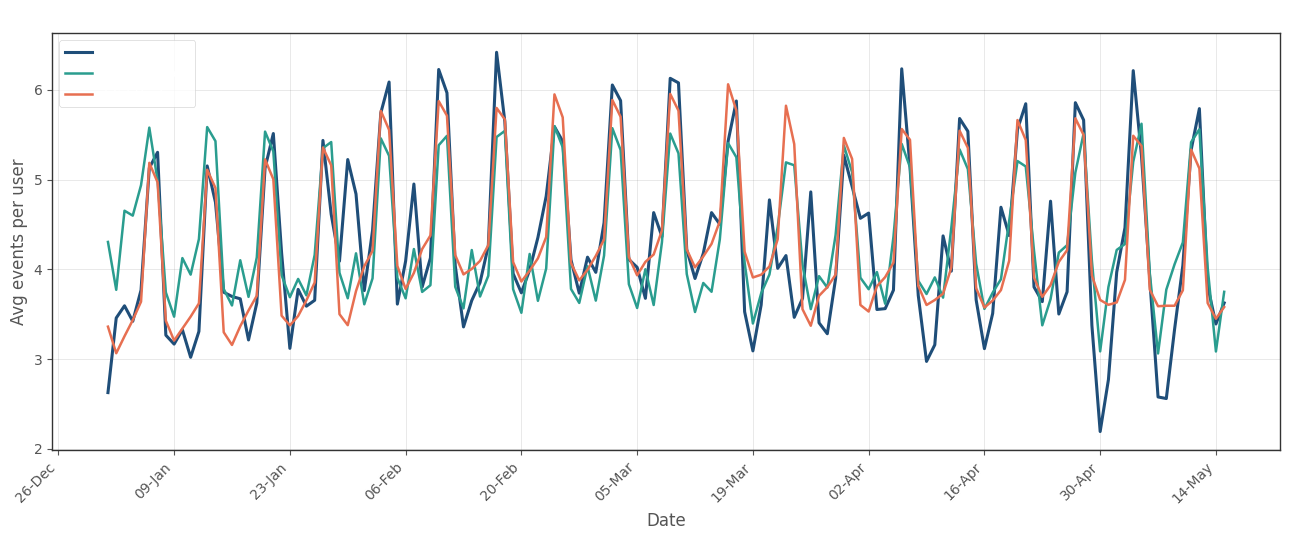

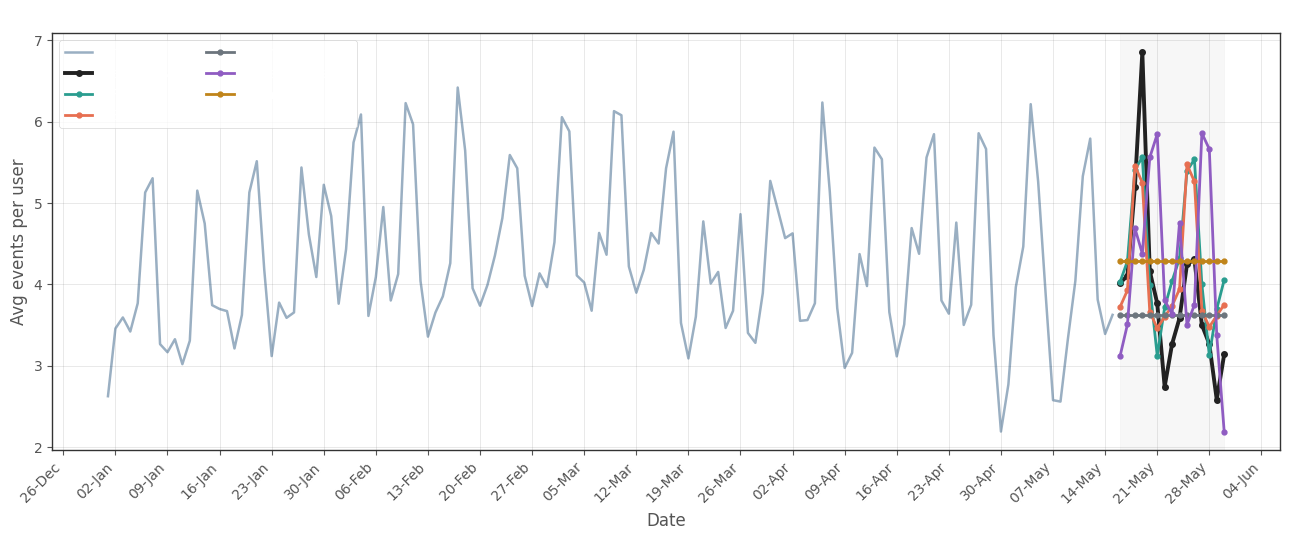

In [13]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train.index, train, label='Train', linewidth=2.2, color=COLORS['train'])
ax.plot(arima_fitted.index, arima_fitted, label='ARIMA fitted', linewidth=1.8, color=COLORS['ARIMA'])
ax.plot(es_fitted.index, es_fitted, label='ES fitted', linewidth=1.8, color=COLORS['ES'])
ax.set_title('In-sample fitted values on the training period')
ax.set_xlabel('Date')
ax.set_ylabel('Avg events per user')
format_date_axis(ax, interval=2)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'insample_fit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train.index, train, label='Train', linewidth=1.8, color=COLORS['train'], alpha=0.45)
ax.plot(test.index, test, label='Test actual', linewidth=2.8, color=COLORS['test'], marker='o', markersize=4)
for method, forecast in forecast_dict.items():
    ax.plot(
        test.index,
        forecast,
        label=method,
        linewidth=2,
        marker='o',
        markersize=3.5,
        color=COLORS[method],
    )
ax.axvspan(test.index.min(), test.index.max(), color='#999999', alpha=0.08)
ax.set_title('15-day forecast comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Avg events per user')
format_date_axis(ax, interval=1)
ax.legend(ncol=2, loc='upper left')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Export for Task 2

The export below is in long format for the dashboard.

In [14]:
actual_rows = pd.DataFrame({
    'ev_date': df.index,
    'method': 'actual',
    'series_type': 'actual',
    'value': df['avg_events_per_user'].values,
    'actual_value': df['avg_events_per_user'].values,
    'forecast_value': np.nan,
    'is_forecast': 0,
    'forecast_day': 0,
    'forecast_week': 0,
    'previous_week_actual': df['avg_events_per_user'].shift(7).values,
    'wow_change': (df['avg_events_per_user'] - df['avg_events_per_user'].shift(7)).values,
    'wow_change_percent': ((df['avg_events_per_user'] - df['avg_events_per_user'].shift(7)) / df['avg_events_per_user'].shift(7) * 100).values,
})

forecast_rows = []
for method, forecast in forecast_dict.items():
    previous_week_actual = df['avg_events_per_user'].reindex(test.index - pd.Timedelta(days=7)).values
    actual_on_test = test.reindex(test.index).values
    forecast_day = np.arange(1, len(test) + 1)
    forecast_week = np.where(forecast_day <= 7, 1, 2)
    forecast_rows.append(pd.DataFrame({
        'ev_date': test.index,
        'method': method,
        'series_type': 'forecast',
        'value': forecast.values,
        'actual_value': actual_on_test,
        'forecast_value': forecast.values,
        'is_forecast': 1,
        'forecast_day': forecast_day,
        'forecast_week': forecast_week,
        'previous_week_actual': previous_week_actual,
        'wow_change': forecast.values - previous_week_actual,
        'wow_change_percent': (forecast.values - previous_week_actual) / previous_week_actual * 100,
    }))

superset_df = pd.concat([actual_rows] + forecast_rows, ignore_index=True)
superset_df = superset_df.sort_values(['ev_date', 'series_type', 'method']).reset_index(drop=True)
superset_df.to_csv(TASK2_OUTPUT, index=False)
superset_df.head(10)


,ev_date,method,series_type,value,actual_value,forecast_value,is_forecast,forecast_day,forecast_week,previous_week_actual,wow_change,wow_change_percent
0,2024-01-01,actual,actual,2.6269,2.6269,NaN,0,0,0,NaN,NaN,NaN
1,2024-01-02,actual,actual,3.4584,3.4584,NaN,0,0,0,NaN,NaN,NaN
2,2024-01-03,actual,actual,3.5941,3.5941,NaN,0,0,0,NaN,NaN,NaN
3,2024-01-04,actual,actual,3.4215,3.4215,NaN,0,0,0,NaN,NaN,NaN
4,2024-01-05,actual,actual,3.7686,3.7686,NaN,0,0,0,NaN,NaN,NaN
5,2024-01-06,actual,actual,5.1295,5.1295,NaN,0,0,0,NaN,NaN,NaN
6,2024-01-07,actual,actual,5.3039,5.3039,NaN,0,0,0,NaN,NaN,NaN
7,2024-01-08,actual,actual,3.2667,3.2667,NaN,0,0,0,2.6269,0.6398,24.355704
8,2024-01-09,actual,actual,3.1673,3.1673,NaN,0,0,0,3.4584,-0.2911,-8.417187
9,2024-01-10,actual,actual,3.3268,3.3268,NaN,0,0,0,3.5941,-0.2673,-7.437189
